In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import qutip
from qutip import *
from qutip import about, basis, destroy, mesolve, ptrace, qeye, tensor, wigner
import math
%matplotlib inline
from scipy.linalg import expm, sinm, cosm

In [2]:
hbar = 1
omegac = 2*np.pi*312.5*10**(3) # field frequency
omega0 = omegac # transition frequency
Omega = 2*np.pi*15.625*10**(3) # coupling strength
phi = 0 #phase of the laser
N = 50  # number of cavity fock states
tlist = np.linspace(0, 250*10**(-6), 251) # Time interval and time steps

#tex_fonts = {
    # Use LaTeX to write all text
#    "text.usetex": True,
#    "font.family": "sans-serif",
#    "font.sans-serif": "amsmath",
    # Use 10pt font in plots, to match 10pt font in document
#    "axes.labelsize": 10,
#    "font.size": 10,
    # Make the legend/label fonts a little smaller
#    "legend.fontsize": 8,
#    "xtick.labelsize": 8,
#    "ytick.labelsize": 8
#}

#plt.rcParams.update(tex_fonts)

In [18]:
sm = 1/2*(sigmax()-1j*sigmay())
sm1 = tensor(sm, qeye(N))
#sigmaz operators 
sz1 = tensor(sigmaz(), qeye(N))
#annihilation operators
a = tensor(qeye(2), destroy(N))
# Time-independent part of the Hamiltonian
H_1 = hbar * Omega * (a * sm1.dag())
H_2 = hbar * Omega * (a.dag() * sm1)
H_a = hbar * omega0 * sz1/2
H_f = hbar * omegac * a.dag()*a
H = H_a + H_f + H_1 + H_2

# Standard QuTiP format to combine the time-dependent and time-independent part
#psi0_A = tensor(basis(2,1)*basis(2,1).dag(),(1/2*coherent(N,0.32)*coherent(N,0.32).dag()+1/2*coherent(N,-0.32)*coherent(N,-0.32).dag()))
psi0_A = tensor(basis(2,1)*basis(2,1).dag(),(0.6*coherent(N,0)*coherent(N,0).dag()+0.4*coherent(N,10)*coherent(N,10).dag()))
#psi0_A = tensor(basis(2,0)*basis(2,0).dag(),(1/2*coherent(N,0.2)*coherent(N,0.2).dag()+0.12747*((coherent(N,0.2)+coherent(N,-0.2))*(coherent(N,0.2)+coherent(N,-0.2)).dag())))
print(np.trace(psi0_A.full()))

#H = [H_a, H_f, [H_1, h_1], [H_2, h_2]]
output1 = mesolve(H, psi0_A, tlist, [], [])

(1+0j)


In [6]:
mixed_state_2 = 1/4*(coherent(N,0.32)+coherent(N,-0.32))*(coherent(N,0.32)+coherent(N,-0.32)).dag()+1/4*(coherent(N,0.32)-coherent(N,-0.32))*(coherent(N,0.32)-coherent(N,-0.32)).dag()
#psi0_B = tensor(basis(2,0)*basis(2,0).dag(),1/2*(coherent(N,0.3*(np.sqrt(2)/2+1j*np.sqrt(2)/2))*coherent(N,0.3*(np.sqrt(2)/2+1j*np.sqrt(2)/2)).dag()+coherent(N,-0.3*(np.sqrt(2)/2+1j*np.sqrt(2)/2))*coherent(N,-0.3*(np.sqrt(2)/2+1j*np.sqrt(2)/2)).dag()))
psi0_B = tensor(basis(2,0)*basis(2,0).dag(),mixed_state_2)
print(np.trace(psi0_B.full()))

output2 = mesolve(H, psi0_B, tlist, [], [])

(0.9999999999999961+0j)


In [32]:
psi0_B = tensor(basis(2,0)*basis(2,0).dag(),1/2*(1/(2*(1+np.exp(-2*0.32**2)))*((coherent(N,0.32)+coherent(N,-0.32))*(coherent(N,0.32)+coherent(N,-0.32)).dag())
                                                +1/(2*(1-np.exp(-2*0.32**2)))*((coherent(N,0.32)-coherent(N,-0.32))*(coherent(N,0.32)-coherent(N,-0.32)).dag())))

print(np.trace(psi0_B.full()))

output2 = mesolve(H, psi0_B, tlist, [], [])

(0.9999999999999994+0j)


In [23]:
psi0_A = tensor(basis(2,0)*basis(2,0).dag(),(1/2*coherent(N,0.15)*coherent(N,0.15).dag()+1/2*coherent(N,-0.15)*coherent(N,-0.15).dag()))
output1 = mesolve(H, psi0_A, tlist, [], [])
mixed_state_2 = 1/4*(coherent(N,0.15)+coherent(N,-0.15))*(coherent(N,0.15)+coherent(N,-0.15)).dag()+1/4*(coherent(N,0.15)-coherent(N,-0.15))*(coherent(N,0.15)-coherent(N,-0.15)).dag()
psi0_B = tensor(basis(2,0)*basis(2,0).dag(),mixed_state_2)
output2 = mesolve(H, psi0_B, tlist, [], [])

In [51]:
mixed_state_A = 1/2*(1/(2*(1+np.exp(-2*0.32**2)))*((coherent(N,0.32)+coherent(N,-0.32))*(coherent(N,0.32)+coherent(N,-0.32)).dag())
                                                +1/(2*(1-np.exp(-2*0.32**2)))*((coherent(N,0.32)-coherent(N,-0.32))*(coherent(N,0.32)-coherent(N,-0.32)).dag()))
mixed_state_B = 1/2*coherent(N,0.32)*coherent(N,0.32).dag()+1/2*coherent(N,-0.32)*coherent(N,-0.32).dag()

relativeentropy_AB_1 = entropy_relative(mixed_state_B, mixed_state_A)
print(relativeentropyAB_1)

0.38464653432006013


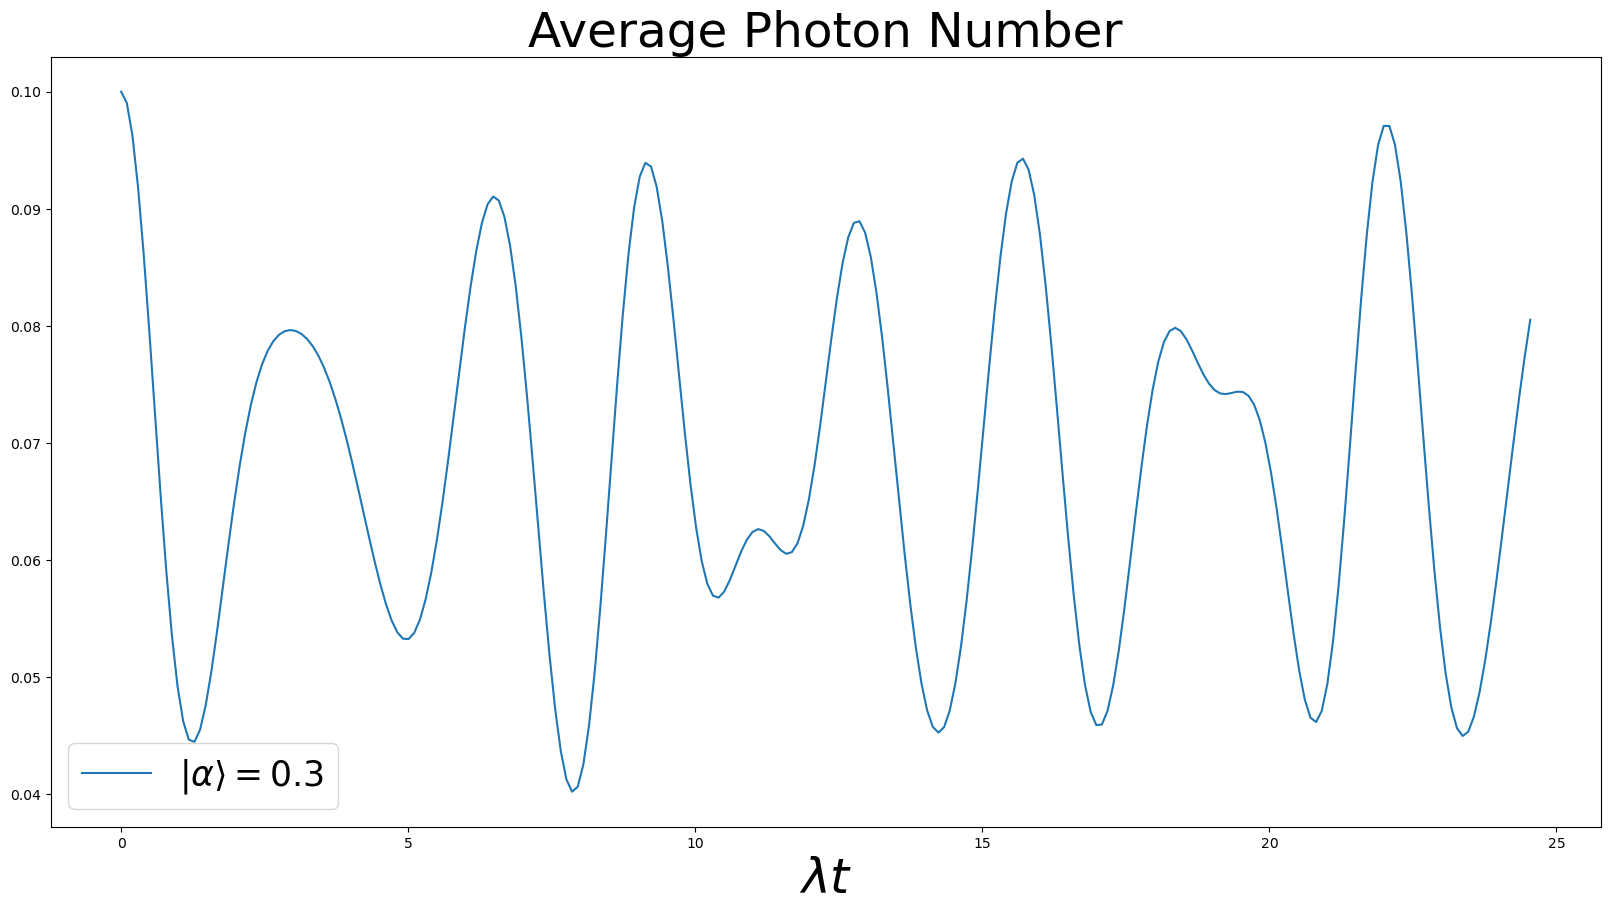

In [5]:
n_a = expect(a.dag()*a, output1.states)
tlist2 = np.linspace(0,250*10**(-6)*Omega,251) # Change the unit of x-axis into microsecond

fig, axes = plt.subplots(1, 1, figsize=(20, 10))
axes.plot(tlist2, n_a, label=r'$|\alpha \rangle=0.3$')
axes.legend(loc= 'best', fontsize = 25)
axes.set_xlabel(r'$ \lambda t$', fontsize = 35)
#axes.set_xlabel("Time ($\\mu s$) ", fontsize = 35)
#axes.set_ylabel("Fidelity", fontsize = 35)
axes.set_title("Average Photon Number", fontsize = 35)

# Run this section twice to change the labelsize
plt.rc('xtick', labelsize=35)    
plt.rc('ytick', labelsize=35) 
#plt.grid(color='black', linestyle='-', linewidth=0.4)
#plt.xlim(0,5)
plt.show()

In [19]:
#output1.states
reduced_density_matrix_A_1 = []
reduced_density_matrix_A_2 = []
for i in range(len(tlist)):
    reduced_density_matrix_A_1.append(output1.states[i].ptrace([0]))
    reduced_density_matrix_A_2.append(output1.states[i].ptrace([1]))

reduced_density_matrix_B_1 = []
reduced_density_matrix_B_2 = []
for i in range(len(tlist)):
    reduced_density_matrix_B_1.append(output2.states[i].ptrace([0]))
    reduced_density_matrix_B_2.append(output2.states[i].ptrace([1]))

#reduced_density_matrix_B_1[0] = Qobj(np.array([[1,0],[0,1]]))

In [146]:
#print(np.trace(reduced_density_matrix_B_2[99].full()))
#print(reduced_density_matrix_B_1)

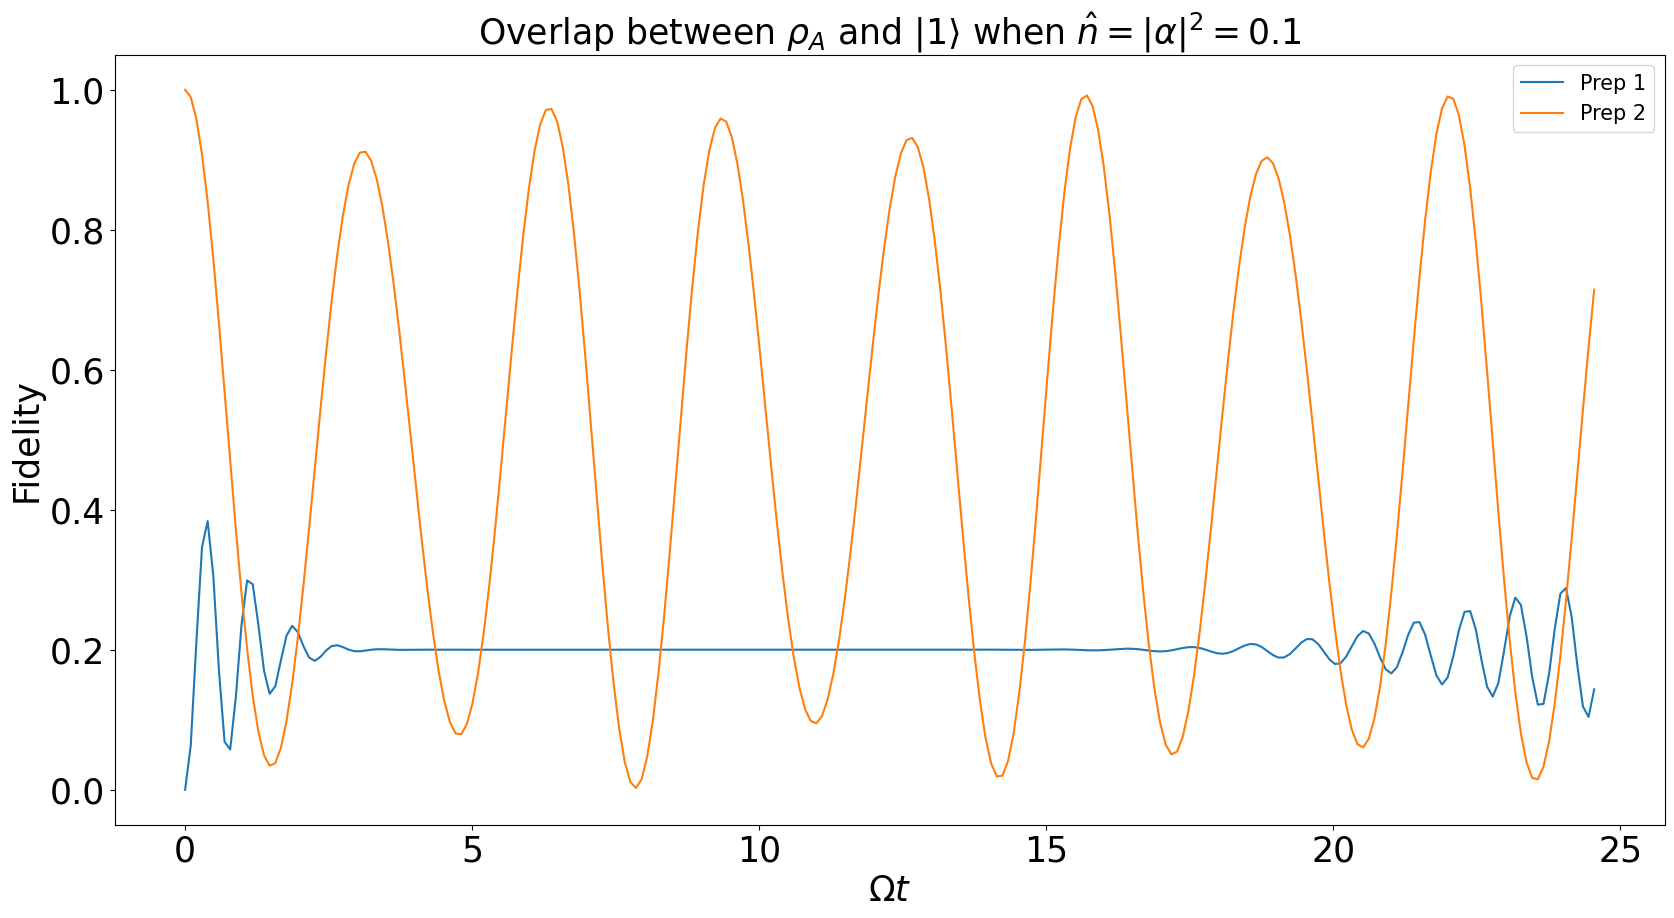

In [20]:
n_a = []
n_b = []
for i in range(len(tlist)):
    n_a.append(expect(reduced_density_matrix_A_1[i], basis(2,0)))
    n_b.append(expect(reduced_density_matrix_B_1[i], basis(2,0)))

fig, axes = plt.subplots(1, 1, figsize=(20, 10))

tlist2 = np.linspace(0,250*10**(-6)*Omega,251) # Change the unit of x-axis into microsecond

axes.plot(tlist2, n_a, label="Prep 1")
axes.plot(tlist2, n_b, label="Prep 2")
axes.legend(loc= 'best', fontsize = 15)
axes.set_xlabel(r'$ \Omega t$', fontsize = 25)
axes.set_ylabel("Fidelity", fontsize = 25)
axes.set_title(r'Overlap between $\rho_A$ and $|1\rangle$ when $\hat{n}=|\alpha|^2=0.1$', fontsize = 25)

plt.rc('xtick', labelsize=25)    
plt.rc('ytick', labelsize=25) 
#plt.grid(color='black', linestyle='-', linewidth=0.4)
#plt.xlim(0,25)
plt.savefig('1')
plt.show()

In [69]:
#print(n_a)
#print(n_a[80])

In [73]:
relativeentropy_AB_2 = []
for i in range(len(tlist2)):
    relativeentropy_AB_2.append(entropy_relative(reduced_density_matrix_A_1[i], reduced_density_matrix_B_1[i]))
#print(relativeentropy_AB_2)

In [75]:
# Convert lists to a 2D NumPy array
data = np.column_stack((tlist2, n_a, n_b))

# Save as CSV (use comma delimiter)
np.savetxt("fidelity_data_3.csv", data, delimiter=",", header="t,fidelity1,fidelity2", comments='')

# Or save as DAT (space-delimited)
np.savetxt("fidelity_data_3.dat", data, delimiter=" ", header="t fidelity1 fidelity2", comments='')

In [44]:
print(max(n_a))

0.9630301111272516


In [20]:
sx1 = tensor(sigmax(), qeye(N))
sy1 = tensor(sigmay(), qeye(N))
sz1 = tensor(sigmaz(), qeye(N))

n_c = expect(sx1,output1.states)
n_c2 = expect(sx1, output2.states)
n_d = expect(sy1,output1.states)
n_d2 = expect(sy1, output2.states)
n_e = expect(sz1,output1.states)
n_e2 = expect(sz1, output2.states)

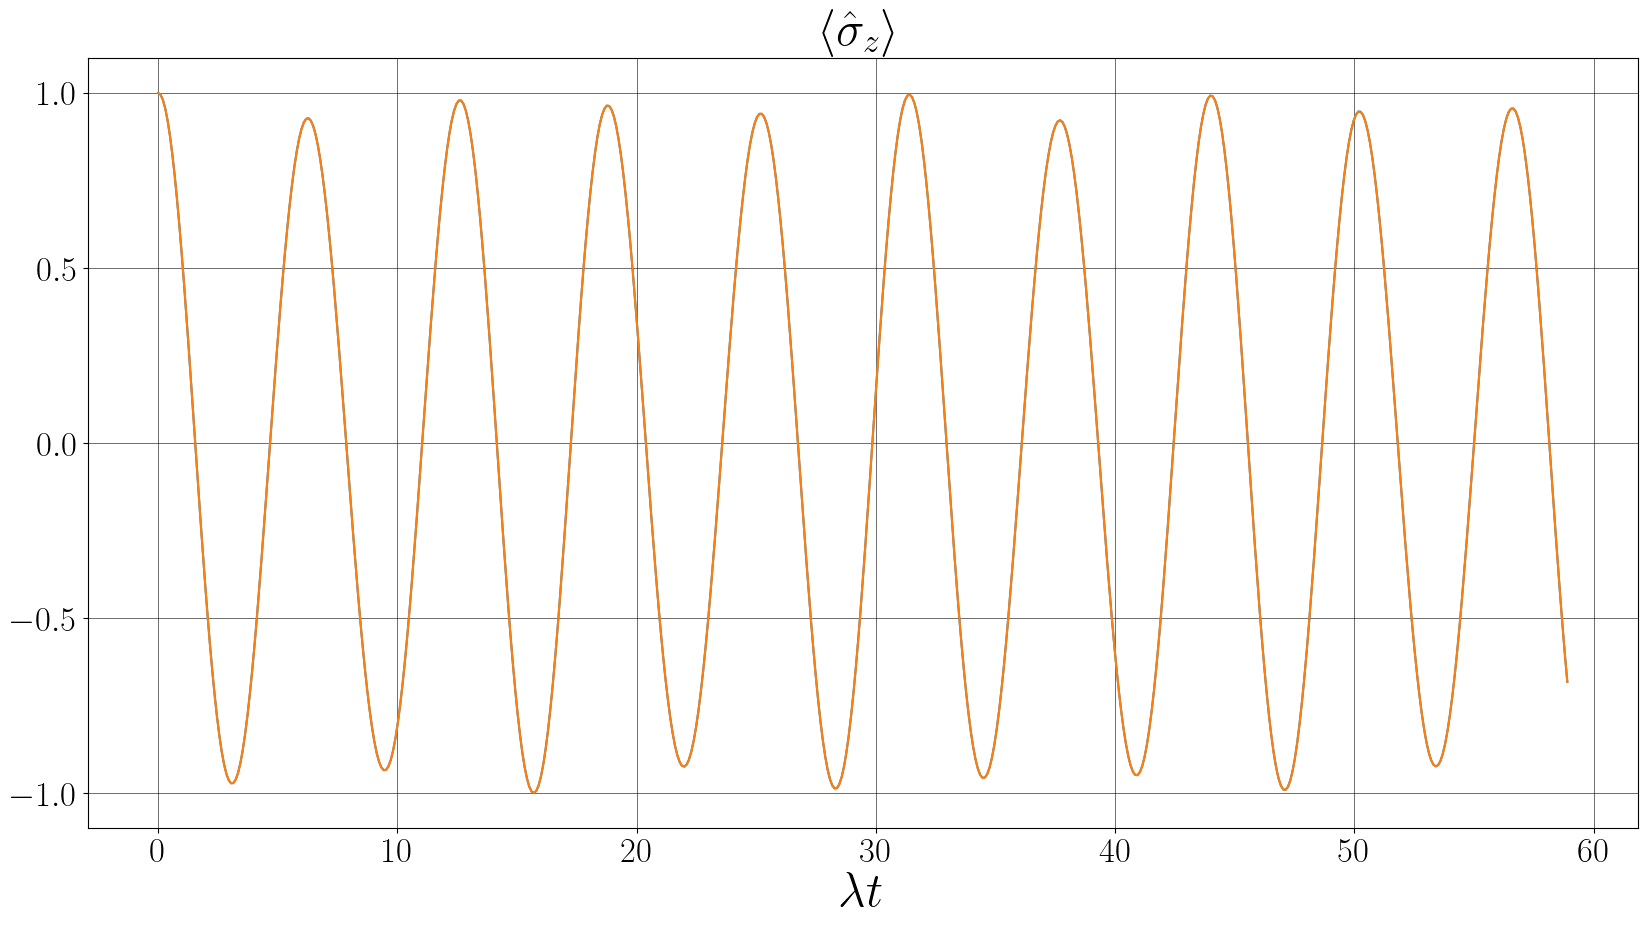

In [22]:
fig, axes = plt.subplots(1, 1, figsize=(20, 10))

tlist2 = np.linspace(0,600*10**(-6)*Omega,601) # Change the unit of x-axis into microsecond

axes.plot(tlist2, n_e, label=r'$<g,0>$')
axes.plot(tlist2, n_e2, label=r'$<e,0>$')
#axes.plot(tlist2, n_c, label=r'$<ge>+<eg>$',color = 'green')
#axes.legend(loc= 'best', fontsize = 25)
axes.set_xlabel(r'$ \lambda t$', fontsize = 35)
#axes.set_xlabel("Time ($\\mu s$) ", fontsize = 35)
#axes.set_ylabel("Atomic Inversion", fontsize = 35)
axes.set_title(r'$\langle \hat{\sigma}_z \rangle$', fontsize = 35)

# Run this section twice to change the labelsize
plt.rc('xtick', labelsize=35)    
plt.rc('ytick', labelsize=35) 
plt.grid(color='black', linestyle='-', linewidth=0.4)
#plt.xlim(0,5)
plt.show()

In [17]:
#print(np.trace((coherent(5,1)*coherent(5,1).dag()).full()))
#print(np.trace((coherent(5,1)*coherent(5,1).dag()*coherent(5,1)*coherent(5,1).dag()).full()))
state_a = 1/2*(1/(2*(1+np.exp(-2*2**2)))*((coherent(N,2)+coherent(N,-2))*(coherent(N,2)+coherent(N,-2)).dag())
                                                +1/(2*(1-np.exp(-2*2**2)))*((coherent(N,2)-coherent(N,-2))*(coherent(N,2)-coherent(N,-2)).dag()))
state_b = state_a*state_a
state_c = basis(2,0)*basis(2,0).dag()
state_d = 0.5*basis(2,0)*basis(2,0).dag()+0.5*basis(2,1)*basis(2,1).dag()
print(np.trace((psi0_A*psi0_A).full()))
print(np.trace((psi0_B*psi0_B).full()))
#logstate_a = np.zeros((10,10))
#for i in range(10):
#    for j in range(10):
#        if state_a.full()[i][j]==0:
#            logstate_a[i][j]=0
#        else:
#            logstate_a[i][j]=np.log(state_a[i][j])
#print(state_a.full(),logstate_a)
#print(np.matmul(state_a.full(),logstate_a))
#print(np.trace(state_a.full()))
#print(-np.trace(state_a.full()*np.log(state_a.full()+1e-10)))
#print(np.trace(state_b.full()))
#eigenvalue_state_a = np.linalg.eigvalsh(state_a.full())
#print(eigenvalue_state_a)
#print(-(0.5*np.log2(0.5)+0.5*np.log2(0.5)))

(0.8488381630355152+0j)
(0.8488381630355152+0j)


In [19]:
entropy_vn(state_d,2)

1.0

In [ ]:
#print(n_b)

In [19]:
systemA_entropy = []
systemB_entropy = []
systemAB_entropy = []

for i in range(251):
    density_matrix = output1.states[i]
    reduced_density_matrix_A = density_matrix.ptrace([0])
    reduced_density_matrix_B = density_matrix.ptrace([1])
    eigenvalues_A = np.linalg.eigvalsh(reduced_density_matrix_A.full())
    #eigenvalues_B = np.linalg.eigvalsh(reduced_density_matrix_B.full())
    #eigenvalues_AB = np.linalg.eigvalsh(density_matrix.full())
    #print(eigenvalues_A,eigenvalues_B,eigenvalues_AB)
    entropy_A = -np.sum(eigenvalues_A * np.log(eigenvalues_A + 1e-10))
    entropy_B = -np.trace(reduced_density_matrix_B.full()*np.log(reduced_density_matrix_B.full() + 1e-15))
    entropy_AB = -np.trace(density_matrix.full()*np.log(density_matrix.full() + 1e-15))
    #entropy_B = -np.sum(eigenvalues_B * np.log2(eigenvalues_B + 1e-10))
    #entropy_AB = -np.sum(eigenvalues_AB * np.log2(eigenvalues_AB + 1e-10))
    systemA_entropy.append(entropy_A)
    systemB_entropy.append(entropy_B)
    systemAB_entropy.append(entropy_AB)
    #print(entropy_A)

In [21]:
systemA_entropy = []
systemB_entropy = []
systemAB_entropy = []
systemAplusB_entropy = []

for i in range(len(tlist)):
    density_matrix = output1.states[i]
    reduced_density_matrix_A = density_matrix.ptrace([0])
    reduced_density_matrix_B = density_matrix.ptrace([1])
    entropy_A = entropy_vn(reduced_density_matrix_A,2)
    entropy_B = entropy_vn(reduced_density_matrix_B,2)
    entropy_AB = entropy_vn(density_matrix,2)
    systemA_entropy.append(entropy_A)
    systemB_entropy.append(entropy_B)
    systemAB_entropy.append(entropy_AB)
    systemAplusB_entropy.append(entropy_A+entropy_B)

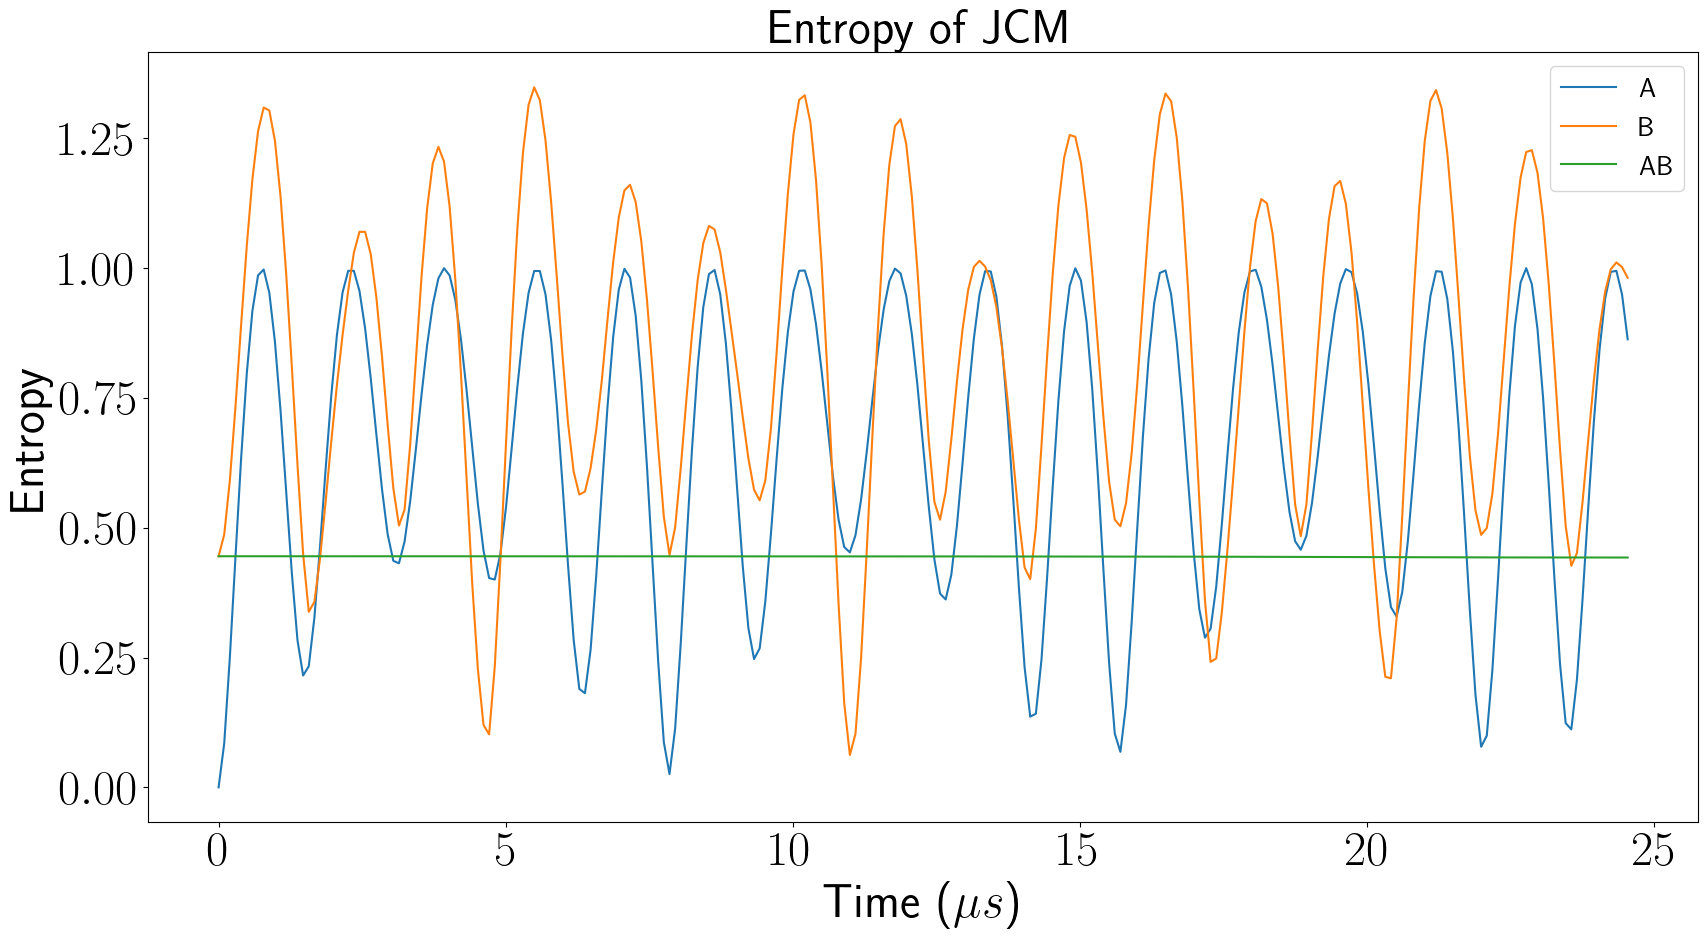

In [26]:
fig, axes = plt.subplots(1, 1, figsize=(20, 10))

tlist2 = np.linspace(0,250*10**(-6)*Omega,251) # Change the unit of x-axis into microsecond

axes.plot(tlist2, systemA_entropy, label='A')
axes.plot(tlist2, systemB_entropy, label='B')
axes.plot(tlist2, systemAB_entropy, label='AB')
#axes.plot(tlist2, systemAplusB_entropy, label='A+B')
axes.legend(loc= 'best', fontsize = 20)
axes.set_xlabel("Time ($\\mu s$) ", fontsize = 35)
axes.set_ylabel("Entropy", fontsize = 35)
axes.set_title("Entropy of JCM", fontsize = 35)

# Run this section twice to change the labelsize
plt.rc('xtick', labelsize=35)    
plt.rc('ytick', labelsize=35) 
#plt.grid(color='black', linestyle='-', linewidth=0.4)
#plt.xlim(0,5)
plt.show()
#fig.savefig('Entropy2')

In [28]:
# Convert lists to a 2D NumPy array
data = np.column_stack((tlist2, systemA_entropy, systemB_entropy, systemAB_entropy))

# Or save as DAT (space-delimited)
np.savetxt("entropy_data_1.dat", data, delimiter=" ", header="t entropy_A entropy_B entropy_AB ", comments='')

In [ ]:
print(displace(4,2))
#print(displace(N,2)*coherent(N,0))
#print(coherent(N,2))
print((2*create(4)-2*destroy(4)).expm())
#print(expm(np.array([[1,1,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]])))

In [38]:
mutual_information = []
for i in range(len(tlist)):
    mutual_information.append(systemA_entropy[i]+systemB_entropy[i]-systemAB_entropy[i])

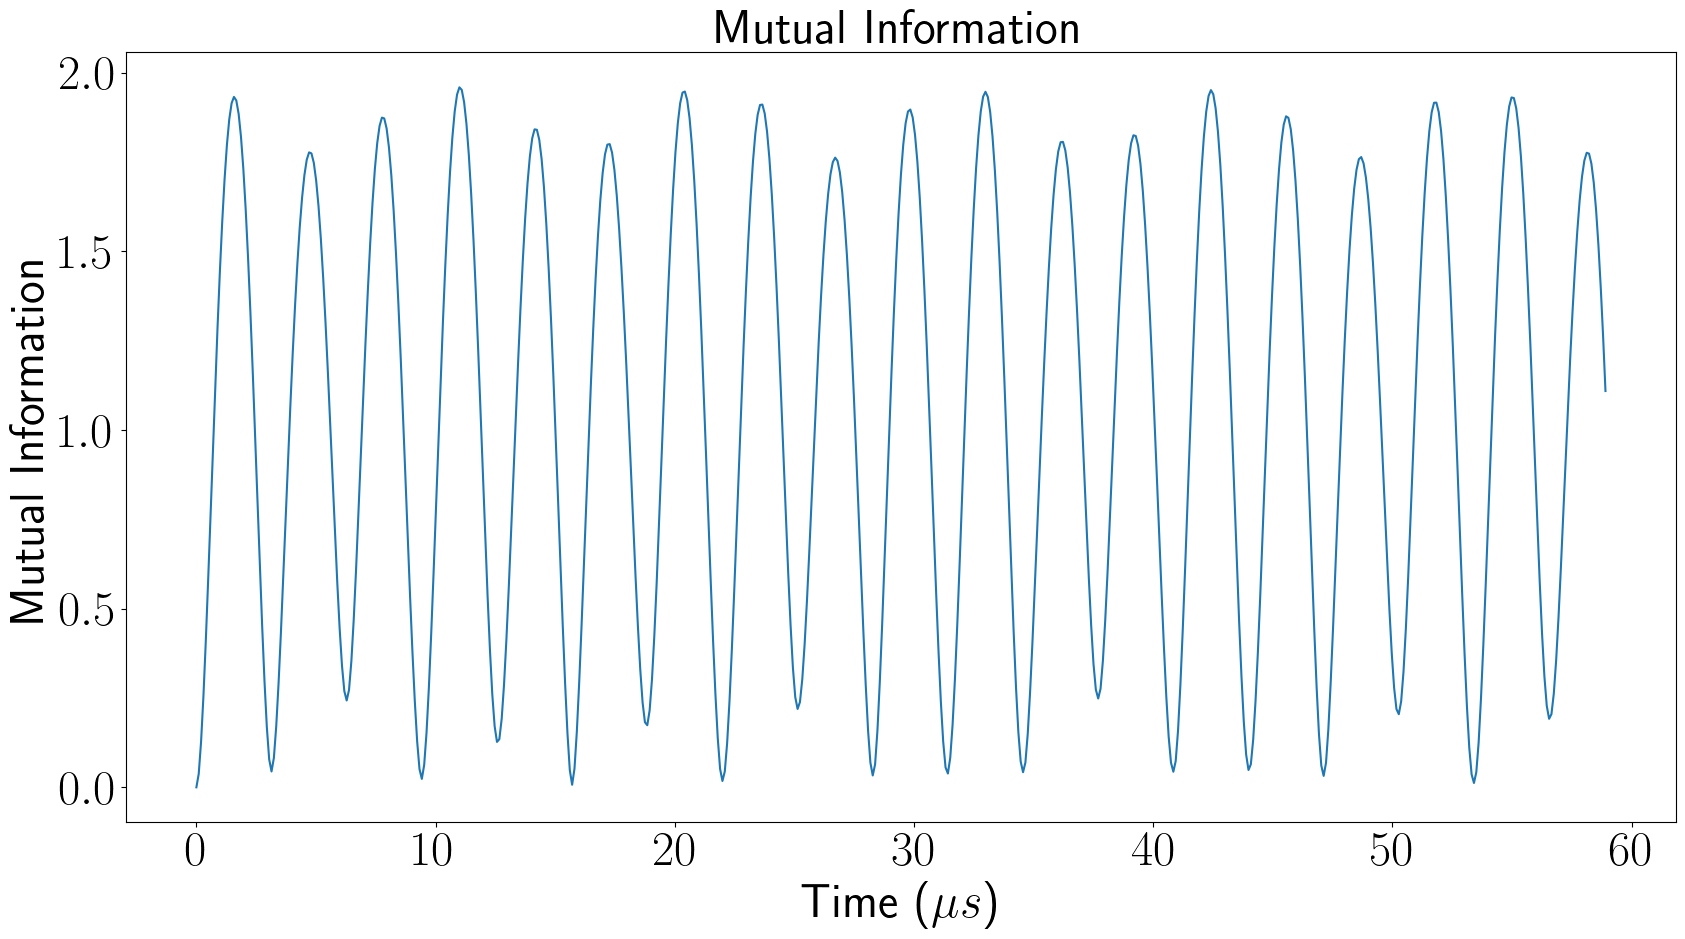

In [62]:
fig, axes = plt.subplots(1, 1, figsize=(20, 10))

tlist2 = np.linspace(0,600*10**(-6)*Omega,601) # Change the unit of x-axis into microsecond

axes.plot(tlist2, mutual_information)
#axes.plot(tlist2, systemAplusB_entropy, label='A+B')
#axes.legend(loc= 'best', fontsize = 25)
axes.set_xlabel("Time ($\\mu s$) ", fontsize = 35)
axes.set_ylabel("Mutual Information", fontsize = 35)
axes.set_title("Mutual Information", fontsize = 35)

# Run this section twice to change the labelsize
plt.rc('xtick', labelsize=35)    
plt.rc('ytick', labelsize=35) 
#plt.grid(color='black', linestyle='-', linewidth=0.4)
#plt.xlim(0,5)
plt.show()
#fig.savefig('Mutual Information')